# Notebook 07 — Modèle Random Forest (affichage des résultats)

**Pourquoi une forêt aléatoire à côté de LightGBM ?** Les deux sont des ensembles d'arbres,
mais ils construisent leur ensemble de façon opposée — et c'est précisément ce qui les rend
complémentaires :

| | LightGBM (*boosting*) | Random Forest (*bagging*) |
|---|---|---|
| Construction | arbres **faibles**, l'un **après** l'autre, chacun corrigeant l'erreur du précédent | arbres **profonds**, **indépendants**, chacun sur un échantillon bootstrap différent |
| Réduit surtout | le **biais** | la **variance** |
| Ajouter des arbres | finit par **sur-apprendre** (d'où l'arrêt anticipé) | ne sur-apprend **jamais** davantage (Breiman 2001) — ça stabilise, c'est tout |
| Régularisation | `num_leaves`, `learning_rate`, arrêt anticipé | **profondeur** des arbres, `min_samples_leaf`, `max_features` |

Deux modèles qui se trompent différemment se **combinent** bien : c'est tout l'objet de la
partie C du notebook 08.

**Ce que le script a fait :**
1. Construire les **mêmes fenêtres** qu'aux notebooks 04, 05 et 06
2. Pour **chaque fenêtre**, entraîner une grille de forêts et retenir celle qui maximise le
   `R²_oos` sur la **validation de cette fenêtre**
3. Mettre bout à bout les prédictions et calculer le **même R²_oos à la GKX**
4. Agréger l'importance des variables sur toutes les fenêtres + calculer les valeurs
   **SHAP** du modèle final (section 6bis)
5. Sauvegarder modèle, prédictions, résultats, et ajouter une ligne au journal


## 0. Import et chargement des résultats

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import config
import rapports

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)

rap = rapports.charger('07_random_forest')
print(rap.resume())

resultats_finaux = pd.read_parquet(config.FICHIER_RESULTATS_RANDOM_FOREST)
resultats_par_fenetre = pd.read_parquet(config.FICHIER_RESULTATS_RANDOM_FOREST_PAR_FENETRE)

Rapport '07_random_forest' produit le 2026-08-15T22:14:22


## 1. Données et fenêtres d'entraînement

In [2]:
print(f"Panel complet : {tuple(rap.valeur('shape_panel'))}")
print(f"Periode disponible dans le panel : {rap.valeur('periode_panel')[0]} a {rap.valeur('periode_panel')[1]}")
print(f"Debut d'entrainement impose (config.ANNEE_DEBUT_ENTRAINEMENT) : {rap.valeur('annee_debut_entrainement')}")
print(f"Panel effectivement utilise : {tuple(rap.valeur('shape_panel_entrainement'))} "
      f"({rap.valeur('periode_entrainement')[0]} a {rap.valeur('periode_entrainement')[1]})")
print(f"Mode : {rap.valeur('type_fenetre')} | {rap.valeur('n_fenetres')} fenetres generees")
print(f"Predicteurs : {rap.valeur('n_predicteurs')}")
rap.table('resume_fenetres')

Panel complet : (2615807, 46)
Periode disponible dans le panel : 198002 a 202112
Debut d'entrainement impose (config.ANNEE_DEBUT_ENTRAINEMENT) : 1980
Panel effectivement utilise : (2615807, 46) (198002 a 202112)
Mode : expanding | 3 fenetres generees
Predicteurs : 30


,fenetre,train_debut,train_fin,n_mois_train,n_annees_train,validation_debut,validation_fin,n_annees_validation,test_debut,test_fin,annee_test
0,0,198002,199712,215,18,199801,200912,12,201001,201312,2010-2013
1,1,198002,200112,263,22,200201,201312,12,201401,201712,2014-2017
2,2,198002,200512,311,26,200601,201712,12,201801,202112,2018-2021


## 2. Le R² hors-échantillon à la Gu, Kelly & Xiu (2020)

Même métrique que les notebooks 04, 05 et 06 — c'est ce qui rend les quatre modèles
comparables au notebook 08 : `R²_oos = 1 - Σ(y - ŷ)² / Σ(y²)`.

## 3. Entraînement fenêtre par fenêtre

Pour chaque fenêtre, le script entraîne toutes les combinaisons de la grille
(`GRILLE_*_RANDOM_FOREST` dans `config.py`) et retient celle qui maximise le `R²_oos` sur la
**validation de cette fenêtre**, jamais sur son test.

⚠️ **Différence avec LightGBM** : il n'y a pas d'arrêt anticipé ici, et il ne peut pas y en
avoir. Les arbres d'une forêt sont **indépendants** : ajouter le 301ᵉ arbre ne corrige rien
du travail des 300 premiers, il ne fait que réduire un peu plus la variance de leur moyenne.
`n_estimators` n'est donc pas un budget qu'on peut interrompre — c'est un simple compromis
stabilité / temps de calcul, et le sur-apprentissage se contrôle ailleurs (`max_depth`,
`min_samples_leaf`, `max_features`).

In [3]:
print("Parametres SPECIFIQUES utilises (config.py) :")
for cle, valeur in rap.valeur('params_specifiques').items():
    print(f"  {cle} = {valeur}")
print()
print(f"Grille : {rap.valeur('n_combinaisons_grille')} combinaisons x "
      f"{rap.valeur('n_fenetres')} fenetres")

# Comment la foret gagnante de chaque fenetre a ete recuperee (config.py) -- ne change aucun
# resultat, seulement le temps de calcul et la memoire.
# `.valeurs.get` plutot que `.valeur` : un rapport produit par une version du script
# ANTERIEURE a l'ajout de GARDER_CANDIDATS_RANDOM_FOREST n'a pas ces cles. On l'affiche alors
# comme tel, au lieu de planter -- il suffit de relancer le script pour les obtenir.
garder_candidats = rap.valeurs.get('garder_candidats')

if garder_candidats is None:
    print("Mode de recuperation du modele : inconnu -- ce rapport a ete produit par une")
    print("version du script anterieure a l'ajout de GARDER_CANDIDATS_RANDOM_FOREST.")
    print("  -> relance `python scripts/entrainer/random_forest_h1.py` pour l'afficher.")
elif garder_candidats:
    print(f"Mode : forets de la grille gardees en memoire "
          f"(~{rap.valeurs.get('memoire_grille_estimee_mo', float('nan')):,.0f} Mo estimes sur "
          f"la plus grande fenetre, {rap.valeurs.get('n_train_maximum', 0):,} lignes), "
          "gagnante reprise telle quelle.")
else:
    print(f"Mode : une seule foret en memoire a la fois, gagnante ré-entrainee "
          f"(+{rap.valeur('n_fenetres')} entrainements au total).")
    if rap.valeurs.get('garder_candidats_demande'):
        print("  ⚠️ Bascule AUTOMATIQUE : GARDER_CANDIDATS_RANDOM_FOREST vaut True, mais la "
              "grille")
        print(f"     est estimee a ~{rap.valeurs.get('memoire_grille_estimee_mo', float('nan')):,.0f} "
              "Mo, au-dela du plafond fixe dans config.py.")
print(f"Duree totale (recherche d'hyperparametres incluse) : "
      f"{rap.valeur('duree_entrainement_secondes'):.1f} s")
print()

resultats_par_fenetre['ecart_train_validation'] = (
    resultats_par_fenetre['r2_oos_train'] - resultats_par_fenetre['r2_oos_validation'])
resultats_par_fenetre.round(4)


Parametres SPECIFIQUES utilises (config.py) :
  grille_n_estimators = [300]
  grille_max_depth = ['3', '5', '8']
  recherche_max_features = deux_temps
  max_features_etape_a = 0.33
  grille_max_features = ['0.66', '1.0']
  grille_min_samples_leaf = [2000]
  max_samples = None

Grille : 3 combinaisons x 3 fenetres
Mode : forets de la grille gardees en memoire (~31 Mo estimes sur la plus grande fenetre, 1,694,462 lignes), gagnante reprise telle quelle.
Duree totale (recherche d'hyperparametres incluse) : 15389.0 s



,fenetre,annee_test,n_train,n_estimators,max_depth,max_features,min_samples_leaf,profondeur_moyenne_arbres,r2_oos_train,r2_oos_oob,r2_oos_validation,r2_oos_test,ecart_train_validation
0,0,2010-2013,1106697,300,8,0.66,2000,8.0,0.0123,0.0103,0.0022,0.0099,0.0101
1,1,2014-2017,1429430,300,8,0.33,2000,8.0,0.0103,0.0087,0.0040,0.0021,0.0063
2,2,2018-2021,1694462,300,5,0.33,2000,5.0,0.0066,0.0061,0.0027,0.0038,0.0039


### 3bis. Le R²_oos *out-of-bag*, une évaluation gratuite propre au bagging

Chaque arbre d'une forêt n'est entraîné que sur un tirage bootstrap du train : en moyenne,
**~37% des observations ne sont vues par aucun arbre donné**. On peut donc prédire chaque
ligne du train uniquement avec les arbres qui **ne l'ont pas vue** — une estimation
hors-échantillon obtenue sans mettre la moindre donnée de côté. Aucun autre modèle du projet
n'offre l'équivalent.

Comment le lire (activé par `OOB_SCORE_RANDOM_FOREST` dans `config.py`) :

- **R²_train ≫ R²_oob** : l'écart mesure directement l'optimisme du score d'entraînement.
  Sur des rendements mensuels, cet écart est normalement large — un R² de train élevé ne
  veut à peu près rien dire.
- **R²_oob ≈ R²_validation** : le modèle est stable, la validation ne tombe pas sur une
  période atypique.
- **R²_oob ≫ R²_validation** : les périodes du train et de la validation ne se ressemblent
  pas (changement de régime de marché) — ce n'est pas un bug du modèle, c'est une information
  sur les données.

,r2_oos_train,r2_oos_oob,r2_oos_validation,r2_oos_test,optimisme_train_vs_oob
annee_test,,,,,
2010-2013,0.0123,0.0103,0.0022,0.0099,0.0020
2014-2017,0.0103,0.0087,0.0040,0.0021,0.0016
2018-2021,0.0066,0.0061,0.0027,0.0038,0.0006


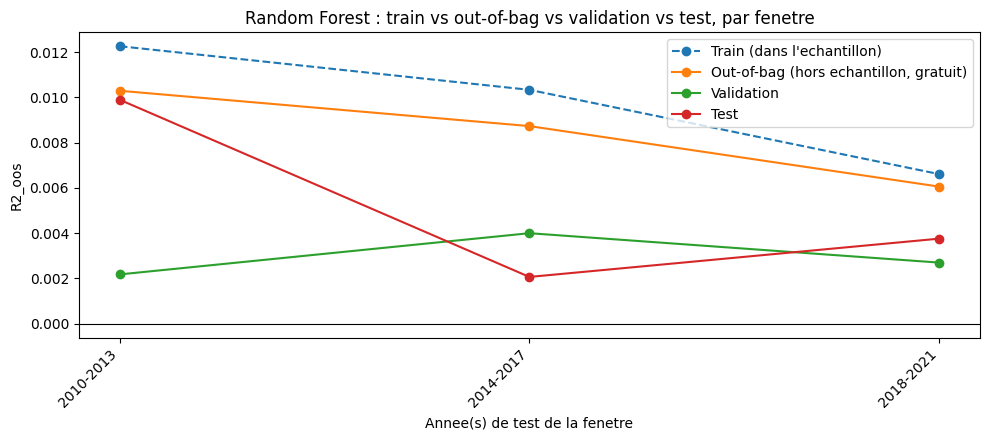

In [4]:
if not rap.valeur('oob_score_actif'):
    print("Le score out-of-bag n'a pas ete calcule (OOB_SCORE_RANDOM_FOREST = False dans config.py).")
else:
    comparaison = resultats_par_fenetre[['annee_test', 'r2_oos_train', 'r2_oos_oob',
                                         'r2_oos_validation', 'r2_oos_test']].copy()
    comparaison['optimisme_train_vs_oob'] = comparaison['r2_oos_train'] - comparaison['r2_oos_oob']
    display(comparaison.round(4).set_index('annee_test'))

    fig, ax = plt.subplots(figsize=(10, 4.5))
    for colonne, etiquette, style in [
        ('r2_oos_train', "Train (dans l'echantillon)", '--'),
        ('r2_oos_oob', "Out-of-bag (hors echantillon, gratuit)", '-'),
        ('r2_oos_validation', "Validation", '-'),
        ('r2_oos_test', "Test", '-'),
    ]:
        ax.plot(resultats_par_fenetre['annee_test'], resultats_par_fenetre[colonne],
                marker='o', linestyle=style, label=etiquette)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xlabel("Annee(s) de test de la fenetre")
    ax.set_ylabel("R2_oos")
    ax.set_title("Random Forest : train vs out-of-bag vs validation vs test, par fenetre")
    ax.legend()
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## 3ter. La grille complète : toutes les forêts testées au dernier lancement

Comme aux notebooks 05 et 06, la section précédente ne montre que la combinaison retenue par
chaque fenêtre, alors que le script en a entraîné bien davantage. La surface de performance
complète en dit plus que son seul maximum : un optimum plat indique un choix robuste, un
optimum pointu peut n'être qu'un artefact du bruit de cette période de validation.

ℹ️ Ces tableaux ne concernent que le **dernier lancement** du script. La comparaison entre
plusieurs lancements est le rôle du notebook 09.

ℹ️ `max_depth = -1` signifie « aucune limite de profondeur » (`None` dans `config.py`) : la
valeur `None` n'est pas stockable en Parquet dans une colonne d'entiers, `-1` sert donc de
code.


In [5]:
grille = rap.table('grille_complete')

# Les deux hyperparametres places sur les axes de la heatmap ci-dessous. Change-les ici si tu
# elargis une autre dimension de la grille dans config.py (ex: AXE_COLONNES = 'max_features').
AXE_LIGNES = 'max_depth'
AXE_COLONNES = 'min_samples_leaf'

print(f"{rap.valeur('n_combinaisons_grille')} combinaisons x {rap.valeur('n_fenetres')} fenetres "
      f"= {rap.valeur('n_modeles_entraines_grille')} forets entrainees au total.")
print()


def _etiquettes(valeurs):
    # 1e-05 plutot que 9.999999999999e-06 : les flottants d'une grille se lisent mieux en %g
    return [f"{v:g}" if isinstance(v, float) else str(v) for v in valeurs]


def tracer_heatmap(pivot, titre, etiquette_couleur, cmap, format_valeur="{:.4f}"):
    # Heatmap annotee a partir d'un tableau croise (2 hyperparametres en lignes/colonnes)
    valeurs = pivot.values.astype(float)
    fig, ax = plt.subplots(figsize=(1.7 * len(pivot.columns) + 3.5,
                                    0.75 * len(pivot.index) + 2.5))
    image = ax.imshow(valeurs, cmap=cmap, aspect='auto')

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(_etiquettes(pivot.columns))
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(_etiquettes(pivot.index))
    ax.set_xlabel(pivot.columns.name)
    ax.set_ylabel(pivot.index.name)
    ax.set_title(titre)

    milieu = (np.nanmax(valeurs) + np.nanmin(valeurs)) / 2
    for i in range(valeurs.shape[0]):
        for j in range(valeurs.shape[1]):
            v = valeurs[i, j]
            if np.isnan(v):
                continue
            ax.text(j, i, format_valeur.format(v), ha='center', va='center',
                    fontsize=9, color='white' if v < milieu else 'black')

    fig.colorbar(image, ax=ax, label=etiquette_couleur)
    plt.tight_layout()
    plt.show()


3 combinaisons x 3 fenetres = 15 forets entrainees au total.



### R²_oos de validation, moyenné sur les fenêtres

⚠️ Chaque case est la moyenne sur **toutes les fenêtres** et sur **toutes les valeurs des
hyperparamètres qui ne sont pas sur les axes**. La heatmap donne donc la tendance générale des
deux paramètres qui t'intéressent ; le tableau détaillé plus bas montre chaque combinaison
individuellement.

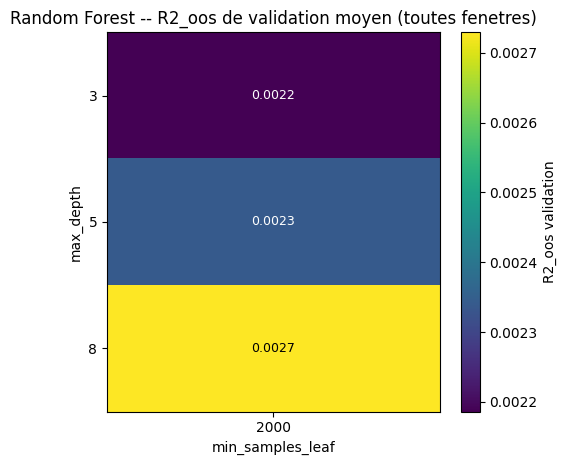

In [6]:
pivot_validation = grille.pivot_table(index=AXE_LIGNES, columns=AXE_COLONNES,
                                      values='r2_oos_validation', aggfunc='mean')
tracer_heatmap(pivot_validation,
               "Random Forest -- R2_oos de validation moyen (toutes fenetres)",
               "R2_oos validation", cmap='viridis')

In [7]:
cles = ['max_depth', 'min_samples_leaf', 'n_estimators', 'max_features']

resume_grille = (grille.groupby(cles)
                 .agg(r2_train=('r2_oos_train', 'mean'),
                      r2_validation=('r2_oos_validation', 'mean'),
                      ecart=('ecart_train_validation', 'mean'),
                      profondeur_moyenne=('profondeur_moyenne_arbres', 'mean'),
                      feuilles_moyennes=('feuilles_moyennes_arbres', 'mean'),
                      fois_selectionnee=('selectionnee', 'sum')))

# Deux rangs plutot que deux tableaux : rang_val = 1 -> meilleure validation,
# rang_ecart = 1 -> ecart train-validation le plus faible (sur-apprend le moins).
resume_grille['rang_val'] = resume_grille['r2_validation'].rank(ascending=False).astype(int)
resume_grille['rang_ecart'] = resume_grille['ecart'].rank().astype(int)
resume_grille = resume_grille.sort_values('max_depth', ascending=False)

print("Toutes les combinaisons, classees par R2_oos de validation moyen.")
print("rang_ecart en regard : une combinaison bien classee sur les DEUX rangs est le")
print("choix le plus sur ; un ecart faible sur un modele qui ne predit rien n'a aucun interet.")
print("profondeur_moyenne : profondeur REELLEMENT atteinte -- si elle reste bien en dessous")
print("du plafond max_depth, c'est min_samples_leaf qui regularise seul.")
resume_grille.round(4)


Toutes les combinaisons, classees par R2_oos de validation moyen.
rang_ecart en regard : une combinaison bien classee sur les DEUX rangs est le
choix le plus sur ; un ecart faible sur un modele qui ne predit rien n'a aucun interet.
profondeur_moyenne : profondeur REELLEMENT atteinte -- si elle reste bien en dessous
du plafond max_depth, c'est min_samples_leaf qui regularise seul.


r2_train  r2_validation   ecart  profondeur_moyenne  \
max_depth min_samples_leaf n_estimators max_features                                                        
8         2000             300          1.0             0.0123         0.0024  0.0098                 8.0   
                                        0.66            0.0119         0.0028  0.0092                 8.0   
                                        0.33            0.0107         0.0029  0.0078                 8.0   
5         2000             300          0.33            0.0071         0.0026  0.0045                 5.0   
                                        0.66            0.0071         0.0022  0.0048                 5.0   
                                        1.0             0.0075         0.0017  0.0057                 5.0   
3         2000             300          0.33            0.0048         0.0022  0.0026                 3.0   

                                                      feuilles_moyennes  fois_selectionnee  rang_val  rang_ecart  
max_depth min_samples_leaf n_estimators max_features                                                              
8         2000             300          1.0                     93.9633                  0         4           7  
                                        0.66                    95.0367                  1         2           6  
                                        0.33                   101.7911                  1         1           5  
5         2000             300          0.33                    28.0311                  1         3           2  
                                        0.66                    29.4367                  0         5           3  
                                        1.0                     29.8300                  0         7           4  
3         2000             300          0.33                     7.9744                  0         6           1

### Exemple détaillé : comment une fenêtre choisit ses hyperparamètres

Le Random Forest est le seul modèle du projet dont la recherche n'est pas un produit
cartésien. `max_features` est arbitré dans une **seconde étape**, une fois les trois autres
axes fixés (voir `config.py`, section « max_features : recherche EN DEUX TEMPS »). On déroule
ici le mécanisme sur une fenêtre, chiffres à l'appui.

In [8]:
FENETRE_EXEMPLE = 0   # <-- change le numero pour illustrer une autre fenetre

# La recherche RF n'est PAS un produit cartesien : la colonne 'etape' vient de boucle.py et
# distingue les forets de l'etape A (max_features fige) de celles de l'etape B.
if 'etape' not in grille.columns:
    print("Ce rapport ne contient pas de colonne 'etape' : il a ete produit par une version")
    print("du script anterieure a la recherche par etapes. Relance le script.")
else:
    ex = grille[grille['fenetre'] == FENETRE_EXEMPLE].copy()
    annee = ex['annee_test'].iloc[0]
    colonnes = ['etape', 'max_depth', 'min_samples_leaf', 'n_estimators', 'max_features',
                'r2_oos_train', 'r2_oos_validation', 'ecart_train_validation', 'selectionnee']

    etape_a = ex[ex['etape'] == 'A'].sort_values('r2_oos_validation', ascending=False)
    etape_b = ex[ex['etape'] == 'B'].sort_values('r2_oos_validation', ascending=False)
    gagnante_a = etape_a.iloc[0]
    retenue = ex[ex['selectionnee']].iloc[0]

    print(f"EXEMPLE DETAILLE -- fenetre {FENETRE_EXEMPLE} (test {annee})")
    print("=" * 78)
    print(f"\nETAPE A -- max_features fige a {config.MAX_FEATURES_ETAPE_A_RANDOM_FOREST}, "
          f"{len(etape_a)} forets :")
    display(etape_a[colonnes].round(5).set_index('etape'))
    print(f"  -> gagnante de l'etape A : max_depth = {gagnante_a['max_depth']}, "
          f"min_samples_leaf = {gagnante_a['min_samples_leaf']:.0f}, "
          f"R2_oos validation = {gagnante_a['r2_oos_validation']:.5f}")

    print(f"\nETAPE B -- ce triplet est FIGE, seul max_features varie, "
          f"{len(etape_b)} forets :")
    display(etape_b[colonnes].round(5).set_index('etape'))

    meilleur_b = etape_b['r2_oos_validation'].max() if len(etape_b) else float('-inf')
    if retenue['etape'] == 'B':
        print(f"  -> l'etape B ameliore : {gagnante_a['r2_oos_validation']:.5f} "
              f"-> {meilleur_b:.5f} "
              f"(+{(meilleur_b - gagnante_a['r2_oos_validation']) * 1e4:.2f} points de base)")
    else:
        print(f"  -> l'etape B n'ameliore pas ({meilleur_b:.5f} contre "
              f"{gagnante_a['r2_oos_validation']:.5f}) : la gagnante de l'etape A est conservee.")

    print(f"\nCOMBINAISON FINALEMENT RETENUE (etape {retenue['etape']}) :")
    print(f"  max_depth = {retenue['max_depth']} | "
          f"min_samples_leaf = {retenue['min_samples_leaf']:.0f} | "
          f"n_estimators = {retenue['n_estimators']:.0f} | "
          f"max_features = {retenue['max_features']}")
    print(f"  R2_oos validation = {retenue['r2_oos_validation']:.5f} | "
          f"R2_oos test = "
          f"{resultats_par_fenetre.set_index('fenetre').loc[FENETRE_EXEMPLE, 'r2_oos_test']:.5f}")
    print(f"\n  Cout : {len(ex)} forets, contre "
          f"{len(etape_a) * (1 + len(etape_b))} en produit cartesien complet.")

EXEMPLE DETAILLE -- fenetre 0 (test 2010-2013)

ETAPE A -- max_features fige a 0.33, 3 forets :


,max_depth,min_samples_leaf,n_estimators,max_features,r2_oos_train,r2_oos_validation,ecart_train_validation,selectionnee
etape,,,,,,,,
A,8,2000,300,0.33,0.01117,0.00210,0.00907,False
A,5,2000,300,0.33,0.00808,0.00145,0.00663,False
A,3,2000,300,0.33,0.00577,0.00091,0.00486,False


  -> gagnante de l'etape A : max_depth = 8, min_samples_leaf = 2000, R2_oos validation = 0.00210

ETAPE B -- ce triplet est FIGE, seul max_features varie, 2 forets :


,max_depth,min_samples_leaf,n_estimators,max_features,r2_oos_train,r2_oos_validation,ecart_train_validation,selectionnee
etape,,,,,,,,
B,8,2000,300,0.66,0.01226,0.00218,0.01008,True
B,8,2000,300,1.0,0.01247,0.00198,0.01049,False


  -> l'etape B ameliore : 0.00210 -> 0.00218 (+0.79 points de base)

COMBINAISON FINALEMENT RETENUE (etape B) :
  max_depth = 8 | min_samples_leaf = 2000 | n_estimators = 300 | max_features = 0.66
  R2_oos validation = 0.00218 | R2_oos test = 0.00990

  Cout : 5 forets, contre 9 en produit cartesien complet.


### L'écart train − validation : quelle combinaison sur-apprend le moins ?

Sur une forêt, cet écart se lit un peu différemment que sur LightGBM. Des arbres profonds
atteignent facilement un R² de train énorme (chaque feuille finit par isoler quelques
titres-mois), sans que ça dise quoi que ce soit de leur pouvoir prédictif.

- **Écart large et positif** → sur-apprentissage. Les coupables habituels : `max_depth` trop
  grand ou absent, ou `min_samples_leaf` trop petit.
- **Écart proche de zéro** → le modèle généralise. Sur des rendements mensuels, ça se trouve
  du côté des arbres **très peu profonds** et des feuilles **larges**.
- **Écart négatif** → le modèle n'apprend presque rien et prédit quasiment zéro partout.

⚠️ Diagnostic, pas critère de sélection : le script choisit toujours sur le meilleur `R²_oos`
de validation. Pour sélectionner sur l'écart, il faut modifier la ligne
`index_meilleur = ...` dans `entrainement/boucle.py` — ce qui changerait du même coup les
quatre modèles et les deux horizons.


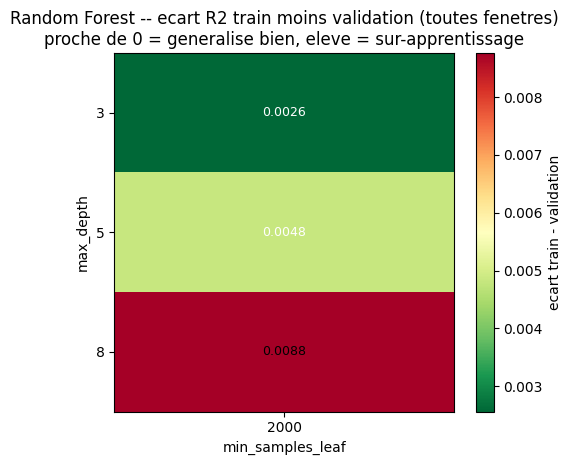

In [9]:
pivot_ecart = grille.pivot_table(index=AXE_LIGNES, columns=AXE_COLONNES,
                                 values='ecart_train_validation', aggfunc='mean')
tracer_heatmap(pivot_ecart,
               "Random Forest -- ecart R2 train moins validation (toutes fenetres)\n"
               "proche de 0 = generalise bien, eleve = sur-apprentissage",
               "ecart train - validation", cmap='RdYlGn_r')

## 4. Évaluation hors-échantillon pooled (toutes les fenêtres bout à bout)

Même logique qu'aux notebooks 04, 05 et 06 : toutes les prédictions bout à bout **d'abord**,
puis un seul R²_oos sur chaque série complète — plutôt qu'une moyenne (biaisée) des R² par
fenêtre.

In [10]:
ligne = resultats_finaux.iloc[0]
print(f"R2_oos train      (pooled, toutes fenetres) : {ligne['r2_oos_train']:.4f}")
print(f"R2_oos validation (pooled, toutes fenetres) : {ligne['r2_oos_validation']:.4f}")
print(f"R2_oos test       (pooled, toutes fenetres) : {ligne['r2_oos_test']:.4f}")
print()
resultats_finaux

R2_oos train      (pooled, toutes fenetres) : 0.0092
R2_oos validation (pooled, toutes fenetres) : 0.0028
R2_oos test       (pooled, toutes fenetres) : 0.0048



,modele,type_fenetre,n_fenetres,r2_oos_train,r2_oos_validation,r2_oos_test,cle_experience
0,Random Forest,expanding,3,0.0092,0.002797,0.004824,6465a9b8c2e081b9


## 5. Évolution du R²_oos et de la profondeur retenue au fil des fenêtres

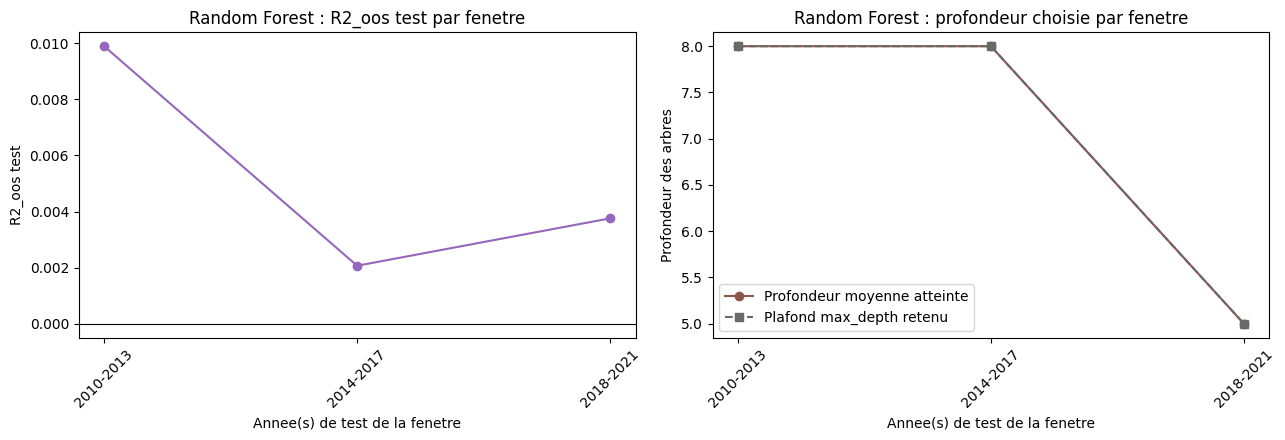

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(resultats_par_fenetre['annee_test'], resultats_par_fenetre['r2_oos_test'],
             marker='o', color='tab:purple')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_xlabel("Annee(s) de test de la fenetre")
axes[0].set_ylabel("R2_oos test")
axes[0].set_title("Random Forest : R2_oos test par fenetre")
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(resultats_par_fenetre['annee_test'],
             resultats_par_fenetre['profondeur_moyenne_arbres'],
             marker='o', color='tab:brown', label="Profondeur moyenne atteinte")
axes[1].plot(resultats_par_fenetre['annee_test'],
             resultats_par_fenetre['max_depth'].replace(-1, np.nan),
             marker='s', linestyle='--', color='dimgray', label="Plafond max_depth retenu")
axes[1].set_xlabel("Annee(s) de test de la fenetre")
axes[1].set_ylabel("Profondeur des arbres")
axes[1].set_title("Random Forest : profondeur choisie par fenetre")
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Importance des variables, fenêtre par fenêtre

L'importance native d'une forêt est la **MDI** (*mean decrease in impurity*) : la réduction
totale d'erreur apportée par les coupures utilisant chaque variable, moyennée sur tous les
arbres. Elle est normalisée à 100 par fenêtre, exactement comme le `gain` de LightGBM au
notebook 06 — les deux notebooks se lisent donc sur la même échelle.

La heatmap ci-dessous croise les **25 variables les plus importantes en moyenne** (en
ordonnée, de la moins importante près de l'origine à la plus importante en haut) avec les
**fenêtres** (en abscisse, dans l'ordre chronologique). Une bande horizontale de couleur
constante signale une variable dont l'importance ne bouge pas dans le temps ; une case isolée
très foncée signale au contraire une variable qui n'a compté que sur une période.


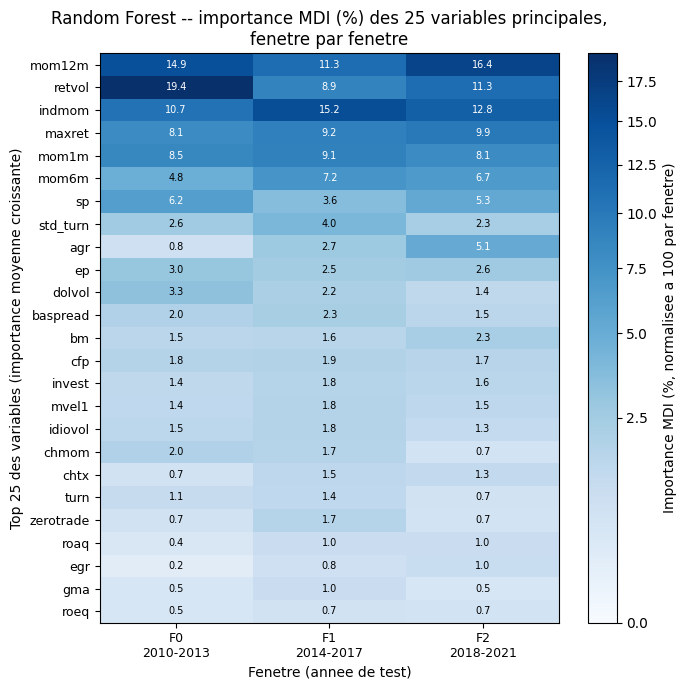

In [12]:
from matplotlib.colors import PowerNorm


# Heatmap : top 25 des variables (lignes) x fenetres (colonnes).
# La MDI est deja normalisee a 100 par fenetre par le script, donc les colonnes sont
# comparables entre elles.
importance_par_fenetre = rap.table('importance_par_fenetre')   # lignes = fenetres, colonnes = variables
resultats_par_fenetre = resultats_par_fenetre.sort_values('fenetre')

N_TOP = 25
TAILLE_FIGURE = (7, 7)          # <-- largeur, hauteur, en pouces

# Classement par importance MOYENNE sur toutes les fenetres, croissant : la plus importante
# se retrouve en haut avec origin='lower' (la moins importante pres de l'origine).
importance_moyenne = importance_par_fenetre.mean()
top = importance_moyenne.nlargest(N_TOP).sort_values(ascending=True).index

matrice = importance_par_fenetre.loc[resultats_par_fenetre['fenetre'], top].T
valeurs = matrice.values.astype(float)

# Etiquettes de colonnes : "F1\n2005" -- le numero de fenetre ET son annee de test
etiquettes_x = [f"F{int(f)}\n{a}" for f, a in
                zip(resultats_par_fenetre['fenetre'], resultats_par_fenetre['annee_test'])]

fig, ax = plt.subplots(figsize=TAILLE_FIGURE)
image = ax.imshow(valeurs, cmap='Blues', aspect='auto', origin='lower',
                  norm=PowerNorm(gamma=0.5, vmin=0, vmax=valeurs.max()))

ax.set_xticks(range(valeurs.shape[1]))
ax.set_xticklabels(etiquettes_x, fontsize=9)
ax.set_yticks(range(valeurs.shape[0]))
ax.set_yticklabels(matrice.index, fontsize=9)
ax.set_xlabel("Fenetre (annee de test)")
ax.set_ylabel(f"Top {N_TOP} des variables (importance moyenne croissante)")
ax.set_title(f"Random Forest -- importance MDI (%) des {N_TOP} variables principales,\n"
             "fenetre par fenetre")

milieu = float(image.norm.inverse(0.5))
for i in range(valeurs.shape[0]):
    for j in range(valeurs.shape[1]):
        v = valeurs[i, j]
        if np.isnan(v):
            continue
        ax.text(j, i, f"{v:.1f}", ha='center', va='center', fontsize=7,
                color='white' if v > milieu else 'black')

fig.colorbar(image, ax=ax, label="Importance MDI (%, normalisee a 100 par fenetre)")
plt.tight_layout()
plt.savefig(config.OUTPUTS_DIR / "importance_random_forest_par_fenetre.png",
            dpi=300, bbox_inches='tight')
plt.show()


## 6bis. Importance agrégée sur toutes les fenêtres (+ SHAP)

L'importance de la **dernière fenêtre** seule peut être trompeuse : d'une fenêtre à l'autre,
la forêt redistribue son importance entre variables corrélées sans que son pouvoir prédictif
change. On regarde donc la moyenne **avec son écart-type** et le **rang moyen** de chaque
variable sur toutes les fenêtres — le rang moyen est plus robuste que la moyenne des
pourcentages, qu'une seule fenêtre atypique peut déformer.

⚠️ **Limite connue de la MDI** (Strobl et al., 2007) : elle favorise les variables à forte
cardinalité, et entre deux variables corrélées elle attribue le crédit de façon largement
arbitraire. Les caractéristiques de GKX étant fortement corrélées entre elles, ce classement
se lit comme un **ordre de grandeur**, jamais comme une hiérarchie exacte — d'où la section
SHAP juste après.

In [13]:
importance_agregee = pd.read_parquet(config.FICHIER_IMPORTANCE_RANDOM_FOREST)

print(f"Importance agregee sur {rap.valeur('n_fenetres')} fenetres.")
print(f"{rap.valeur('imp_n_jamais_utilisees')} / {rap.valeur('imp_n_predicteurs')} predicteurs "
      "ne sont utilises dans AUCUN arbre d'aucune fenetre.")
print()
print("Top 20 des predicteurs (avec leur variabilite d'une fenetre a l'autre) :")
importance_agregee.head(20).round(3)

Importance agregee sur 3 fenetres.
0 / 30 predicteurs ne sont utilises dans AUCUN arbre d'aucune fenetre.

Top 20 des predicteurs (avec leur variabilite d'une fenetre a l'autre) :


,importance_moyenne_pct,importance_ecart_type_pct,rang_moyen,jamais_utilisee_pct_fenetres
mom12m,14.186,2.635,1.667,0.0
retvol,13.183,5.468,3.000,0.0
indmom,12.914,2.242,2.000,0.0
maxret,9.060,0.938,4.000,0.0
mom1m,8.561,0.521,4.333,0.0
mom6m,6.222,1.262,6.333,0.0
sp,5.064,1.320,7.000,0.0
std_turn,2.983,0.936,9.333,0.0
agr,2.882,2.157,12.000,0.0
ep,2.696,0.274,9.333,0.0


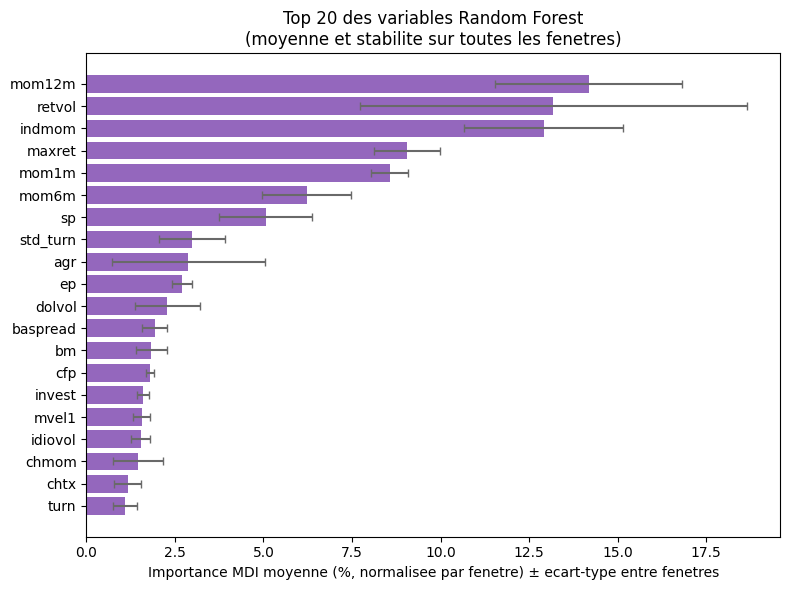

In [14]:
top20_imp = importance_agregee.head(20).sort_values('importance_moyenne_pct')

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top20_imp.index, top20_imp['importance_moyenne_pct'],
        xerr=top20_imp['importance_ecart_type_pct'], color='tab:purple',
        ecolor='dimgray', capsize=3)
ax.set_xlabel("Importance MDI moyenne (%, normalisee par fenetre) ± ecart-type entre fenetres")
ax.set_title("Top 20 des variables Random Forest\n(moyenne et stabilite sur toutes les fenetres)")
plt.tight_layout()
plt.show()

### SHAP — contributions signées du modèle de la dernière fenêtre

Contrairement à la MDI (agrégée, sans direction, et biaisée entre variables corrélées), SHAP
(Lundberg & Lee, 2017) donne une contribution **signée** par variable et par observation —
utile pour voir non seulement *quelles* variables comptent, mais aussi *dans quel sens*.

⚠️ Les valeurs SHAP sont **calculées par le script** et stockées dans le rapport : la cellule
ci-dessous ne fait que tracer le graphique. Sur une forêt, l'explainer est nettement plus lent
que sur LightGBM (arbres bien plus gros), d'où un échantillon plus petit qu'au notebook 06 —
et l'option `--sans-shap` si le temps de calcul devient gênant.

c:\Users\aless\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


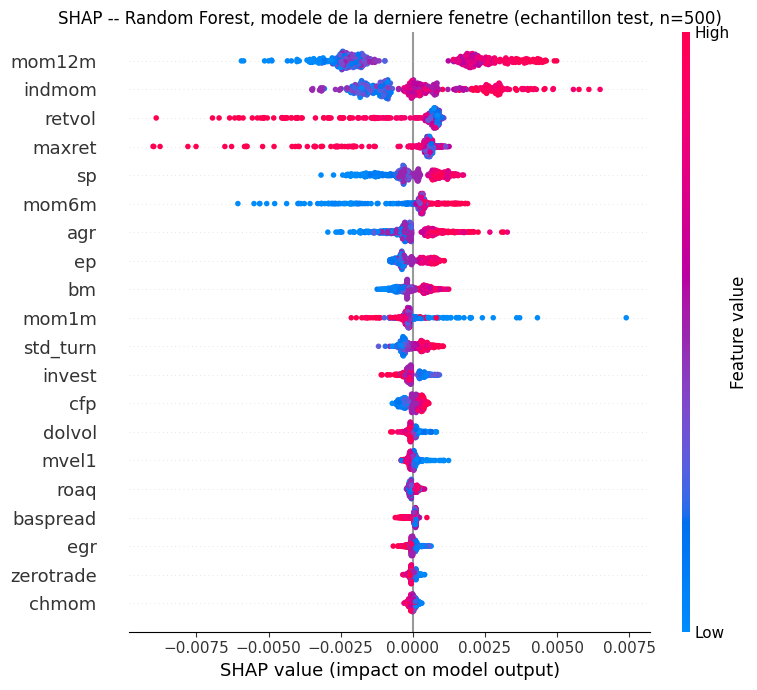

Graphique sauvegarde : C:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\Memoire\Memoire\outputs\shap_random_forest_derniere_fenetre.png


In [15]:
if not rap.valeur('shap_calcule'):
    print("Les valeurs SHAP n'ont pas ete calculees (package 'shap' absent, ou script lance")
    print("avec --sans-shap). Pour les obtenir : pip install shap, puis")
    print("    python scripts/entrainer/random_forest_h1.py")
else:
    import shap

    valeurs_shap = rap.table('shap_valeurs')
    X_echantillon = rap.table('shap_echantillon_X')
    n = rap.valeur('shap_taille_echantillon')

    shap.summary_plot(valeurs_shap.values, X_echantillon, max_display=20, show=False)
    fig = plt.gcf()
    fig.set_size_inches(8, 7)
    plt.title(f"SHAP -- Random Forest, modele de la derniere fenetre (echantillon test, n={n})")
    plt.tight_layout()
    plt.savefig(config.OUTPUTS_DIR / "shap_random_forest_derniere_fenetre.png", dpi=150)
    plt.show()
    print("Graphique sauvegarde :", config.OUTPUTS_DIR / "shap_random_forest_derniere_fenetre.png")


## 9. Résumé et prochaines étapes

- Hyperparamètres (`max_depth`, `min_samples_leaf`, `max_features`, `n_estimators`) choisis
  par grille sur la `validation` de **chaque fenêtre**, comme aux notebooks 05 et 06.
- Pas d'arrêt anticipé : les arbres d'une forêt sont indépendants, la régularisation passe par
  leur **profondeur** et la taille de leurs feuilles.
- **R²_oos out-of-bag** (section 3bis) : une évaluation hors-échantillon gratuite, sans mettre
  la moindre donnée de côté — propre au bagging, impossible sur les trois autres modèles.
- **Importance (section 6bis)** : MDI moyennée (avec écart-type et rang moyen) sur **toutes**
  les fenêtres, complétée par une analyse SHAP signée du modèle final.

**Étape suivante :** les 4 modèles sont entraînés — ouvre
`08_evaluation_portefeuilles.ipynb` (portefeuilles long-short par décile, **et portefeuille
combiné** en partie C), puis `09_comparaison_experiences.ipynb` (comparaison de tous les
lancements passés).